# 05 v2 · Hypnodensity–feature correlations

Este notebook usa el análisis pooled como análisis principal: todas las épocas y todos los electrodos monoelectrodo disponibles se analizan conjuntamente. Los análisis por electrodo y por segmento se conservan únicamente como análisis de sensibilidad numérico, para comprobar si la relación entre las probabilidades inferidas por GSSC y los features depende del canal o de la etapa del registro.

Se incluyen únicamente GSSC, las probabilidades de W/N1/R y la entropía normalizada. Se excluyen todos los features de YASA; el conjunto queda restringido a bandpower, Catch22 y SpecParam.

## i) Imports, parámetros y estilo gráfico

Se reciclan las funciones de ensamblado, unión, correlación y exportación del proyecto. Las figuras se exportan en PNG, SVG y PDF, con la configuración tipográfica Liberation Sans usada en el notebook 02. No se usan suptitles.

In [34]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from dmt_hypnodensities import (
    add_hypnodensity_entropy, assemble_outputs, feature_value_columns,
    join_epoch_features_hypnodensities, load_config, save_figure, save_table,
    stage_feature_effect_correlations,
)

sns.reset_defaults()
plt.rcParams.update({
    'font.family': 'Liberation Sans', 'font.sans-serif': ['Liberation Sans'], 'font.size': 14,
    'axes.titlesize': 14, 'axes.labelsize': 13, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 11, 'svg.fonttype': 'none',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
CONFIG_PATH = next(p.resolve() for p in (Path('configs/analysis.yaml'), Path('../configs/analysis.yaml')) if p.is_file())
RUN_NAME = 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RESULTS_NAME = 'feature_hypnodensity_correlations_000s_gssc_v2'
STAGER = 'gssc'
STAGES = ('W', 'N1', 'R', 'entropy')
RESPONSE_COLUMNS = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
PHASES, DOSES = ('before', 'after'), ('placebo', 'DMT')
CORRELATION_METHOD, MIN_OBSERVATIONS, TOP_N = 'spearman', 30, 10
RUN_ROOT = load_config(CONFIG_PATH).output_dir / RUN_NAME
TABLES_DIR = load_config(CONFIG_PATH).output_dir / RESULTS_NAME / 'tables'
FIGURES_DIR = load_config(CONFIG_PATH).output_dir / RESULTS_NAME / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
tables = assemble_outputs(RUN_ROOT / 'recordings', strict=True)
display({'run': RUN_NAME, 'n_feature_rows': len(tables.features), 'n_hypnodensity_rows': len(tables.hypnodensities)})


{'run': 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1',
 'n_feature_rows': 54496,
 'n_hypnodensity_rows': 143456}

## ii) Selección de features y categorías Catch22

Las categorías de Catch22 se consolidan en Distribution, Autocorrelation, Symbolic, Self Affine y Other. Autocorrelation incluye las variantes lineal y no lineal. Other incluye extreme timing, simple forecasting, incremental differences y embedding_dist. Bandpower y SpecParam se mantienen como categorías propias.

In [35]:
CATCH22_CATEGORIES = {
    'c22_DN_HistogramMode_5':'Distribution', 'c22_DN_HistogramMode_10':'Distribution',
    'c22_DN_OutlierInclude_p_001_mdrmd':'Other', 'c22_DN_OutlierInclude_n_001_mdrmd':'Other',
    'c22_CO_f1ecac':'Autocorrelation', 'c22_CO_FirstMin_ac':'Autocorrelation',
    'c22_SP_Summaries_welch_rect_area_5_1':'Autocorrelation', 'c22_SP_Summaries_welch_rect_centroid':'Autocorrelation',
    'c22_FC_LocalSimple_mean3_stderr':'Other', 'c22_FC_LocalSimple_mean1_tauresrat':'Other',
    'c22_MD_hrv_classic_pnn40':'Other', 'c22_SB_BinaryStats_mean_longstretch1':'Symbolic',
    'c22_SB_BinaryStats_diff_longstretch0':'Symbolic', 'c22_SB_MotifThree_quantile_hh':'Symbolic',
    'c22_SB_TransitionMatrix_3ac_sumdiagcov':'Symbolic', 'c22_CO_HistogramAMI_even_2_5':'Autocorrelation',
    'c22_CO_trev_1_num':'Autocorrelation', 'c22_IN_AutoMutualInfoStats_40_gaussian_fmmi':'Autocorrelation',
    'c22_PD_PeriodicityWang_th0_01':'Autocorrelation', 'c22_CO_Embed2_Dist_tau_d_expfit_meandiff':'Other',
    'c22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1':'Self Affine',
    'c22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1':'Self Affine',
}
CATCH22_SHORT_NAMES = {
    'c22_DN_HistogramMode_5':'mode_5', 'c22_DN_HistogramMode_10':'mode_10',
    'c22_DN_OutlierInclude_p_001_mdrmd':'outlier_timing_pos', 'c22_DN_OutlierInclude_n_001_mdrmd':'outlier_timing_neg',
    'c22_CO_f1ecac':'acf_timescale', 'c22_CO_FirstMin_ac':'acf_first_min',
    'c22_SP_Summaries_welch_rect_area_5_1':'low_freq_power', 'c22_SP_Summaries_welch_rect_centroid':'centroid_freq',
    'c22_FC_LocalSimple_mean3_stderr':'forecast_error', 'c22_FC_LocalSimple_mean1_tauresrat':'whiten_timescale',
    'c22_MD_hrv_classic_pnn40':'high_fluctuation', 'c22_SB_BinaryStats_mean_longstretch1':'stretch_high',
    'c22_SB_BinaryStats_diff_longstretch0':'stretch_decreasing', 'c22_SB_MotifThree_quantile_hh':'entropy_pairs',
    'c22_CO_HistogramAMI_even_2_5':'ami2', 'c22_CO_trev_1_num':'trev',
    'c22_IN_AutoMutualInfoStats_40_gaussian_fmmi':'ami_timescale', 'c22_SB_TransitionMatrix_3ac_sumdiagcov':'transition_variance',
    'c22_PD_PeriodicityWang_th0_01':'periodicity', 'c22_CO_Embed2_Dist_tau_d_expfit_meandiff':'embedding_dist',
    'c22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1':'rs_range', 'c22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1':'dfa',
}
CATEGORY_COLORS = {'Bandpower':'#7a5195', 'Distribution':'#f2a900', 'Autocorrelation':'#2a9d8f', 'Symbolic':'#6a994e', 'Self Affine':'#bc6c25', 'Other':'#8c6d5a', 'SpecParam':'#5f6f52'}
def feature_category(feature):
    if feature.startswith('bp_'): return 'Bandpower'
    if feature.startswith('specparam_'): return 'SpecParam'
    category = CATCH22_CATEGORIES.get(feature)
    if category in {'Distribution','Autocorrelation','Symbolic','Self Affine','Other'}: return category
    raise KeyError(f'Feature without category: {feature}')
ALL_FEATURES = feature_value_columns(tables.features)
FEATURES = tuple(f for f in ALL_FEATURES if f.startswith(('bp_', 'c22_', 'specparam_')))
FEATURE_CATEGORY = {f: feature_category(f) for f in FEATURES}
missing = sorted(f for f in FEATURES if f.startswith('c22_') and f not in CATCH22_CATEGORIES)
if missing: raise KeyError(f'Catch22 columns missing from category map: {missing}')
FEATURE_LABEL = {feature: CATCH22_SHORT_NAMES.get(feature, feature) for feature in FEATURES}
display(pd.Series(FEATURE_CATEGORY, name='category').rename_axis('feature').rename(index=FEATURE_LABEL).to_frame())


,category
feature,
bp_rel_delta,Bandpower
bp_rel_theta,Bandpower
bp_rel_alpha,Bandpower
bp_rel_sigma,Bandpower
bp_rel_beta,Bandpower
bp_rel_gamma,Bandpower
specparam_offset,SpecParam
specparam_exponent,SpecParam
specparam_r2,SpecParam


## iii) Tabla analítica a nivel de época

Se añade entropía normalizada a partir de las cinco probabilidades y se filtra GSSC. Se conservan los metadatos de electrodo, fase y condición para los tests de sensibilidad posteriores.

In [36]:
epoch_analysis = join_epoch_features_hypnodensities(tables.features, add_hypnodensity_entropy(tables.hypnodensities), strict=True)
epoch_analysis = epoch_analysis.loc[epoch_analysis['stager'].astype(str).eq(STAGER)].copy()
save_table(epoch_analysis, TABLES_DIR / 'epoch_feature_hypnodensity_filtered.parquet')
display(epoch_analysis.shape)


(54496, 79)

## iv) Análisis principal pooled y ranking por W

La correlación pooled usa todas las observaciones disponibles. El ranking se define exclusivamente con prob_W y se reutiliza en todos los resultados posteriores.

In [37]:
pooled_correlations = stage_feature_effect_correlations(epoch_analysis, stage_columns=RESPONSE_COLUMNS, feature_columns=FEATURES, group_by=('stager',), methods=(CORRELATION_METHOD,), min_observations=MIN_OBSERVATIONS)
pooled_correlations = pooled_correlations.loc[pooled_correlations['stager'].astype(str).eq(STAGER)].copy()
save_table(pooled_correlations, TABLES_DIR / 'pooled_feature_probability_correlations.csv')
pooled_matrix = pooled_correlations.pivot(index='stage', columns='feature', values='correlation').reindex(STAGES)
feature_order = pooled_matrix.loc['W'].sort_values(ascending=False, na_position='last').index.tolist()
ranked_matrix = pooled_matrix.loc[:, feature_order]
display(ranked_matrix.rename(columns=FEATURE_LABEL))


feature,bp_rel_alpha,whiten_timescale,centroid_freq,specparam_error,low_freq_power,stretch_decreasing,ami2,embedding_dist,trev,periodicity,...,acf_first_min,bp_rel_gamma,specparam_exponent,dfa,acf_timescale,stretch_high,bp_rel_theta,rs_range,ami_timescale,bp_rel_delta
stage,,,,,,,,,,,,,,,,,,,,,
W,0.765763,0.686684,0.570166,0.413695,0.308869,0.295017,0.270485,0.185596,0.129529,0.050446,...,-0.289592,-0.414935,-0.423518,-0.501374,-0.509270,-0.611099,-0.684192,-0.703092,-0.765633,-0.890609
N1,-0.730279,-0.660138,-0.534172,-0.399423,-0.332818,-0.318229,-0.274875,-0.209765,-0.129901,-0.073446,...,0.266318,0.442687,0.387314,0.486317,0.469733,0.568607,0.672761,0.676819,0.729153,0.850215
R,-0.732570,-0.693013,-0.514537,-0.443367,-0.418389,-0.386011,-0.312420,-0.255615,-0.151673,-0.083558,...,0.256626,0.497923,0.321830,0.506367,0.433864,0.525985,0.682700,0.699367,0.721409,0.837025
entropy,-0.742962,-0.680025,-0.532205,-0.417302,-0.348904,-0.330052,-0.297396,-0.222921,-0.130767,-0.092324,...,0.253328,0.451590,0.387163,0.509707,0.467002,0.578621,0.673793,0.691907,0.738602,0.865625


## v) Analysis 6 — Feature ranking heatmap, ordered by wakefulness correlation

El primer plot muestra las cuatro respuestas y las features ordenadas por la correlación pooled con W. El color de las etiquetas codifica la categoría del feature.

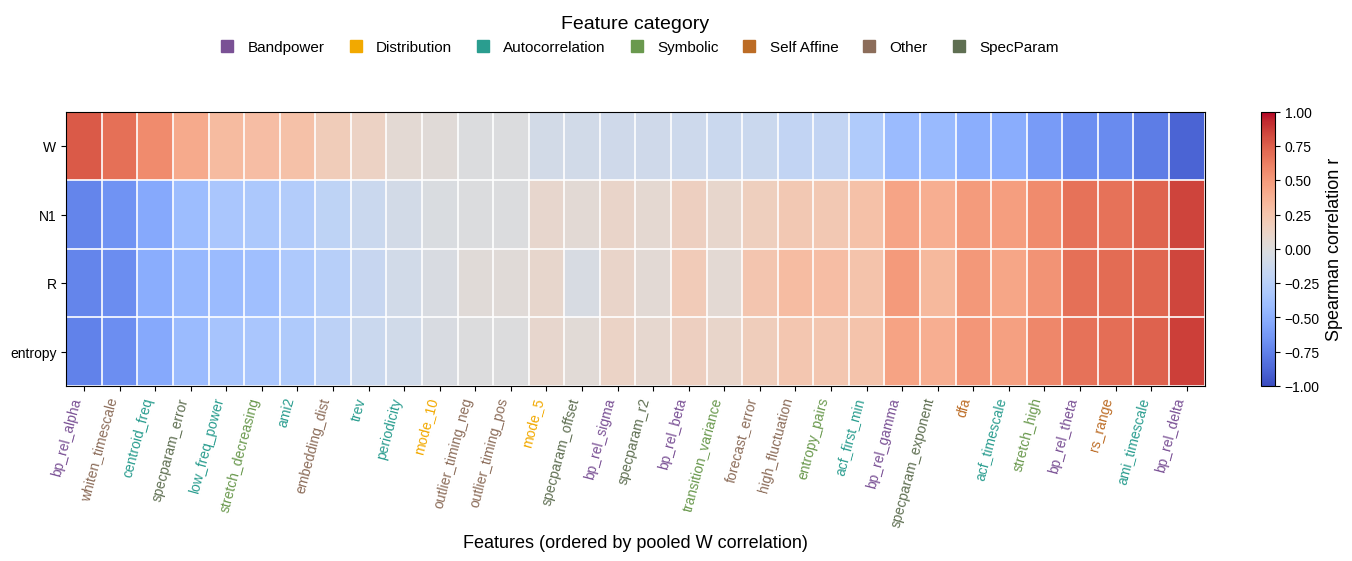

In [38]:
def category_legend(axis):
    handles = [plt.Line2D([0],[0], marker='s', linestyle='', color=c, markersize=9, label=k) for k,c in CATEGORY_COLORS.items()]
    axis.legend(handles=handles, title='Feature category', bbox_to_anchor=(0.5,1.16), loc='lower center', ncol=len(handles), frameon=False, columnspacing=1.0, handletextpad=0.35)
figure, axis = plt.subplots(figsize=(max(12, .42*len(feature_order)), 5.5), constrained_layout=True)
image = axis.imshow(ranked_matrix.to_numpy(float), vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
axis.set_xticks(np.arange(len(feature_order)), [FEATURE_LABEL[f] for f in feature_order], rotation=75, ha='right'); axis.set_yticks(np.arange(len(STAGES)), STAGES)
axis.set_xlabel('Features (ordered by pooled W correlation)'); axis.set_ylabel('')
axis.set_xticks(np.arange(-.5, len(feature_order), 1), minor=True); axis.set_yticks(np.arange(-.5, len(STAGES), 1), minor=True)
axis.grid(False, which='major'); axis.grid(which='minor', color='white', linewidth=1.2); axis.tick_params(which='minor', bottom=False, left=False)
for label, feature in zip(axis.get_xticklabels(), feature_order): label.set_color(CATEGORY_COLORS[FEATURE_CATEGORY[feature]])
figure.colorbar(image, ax=axis, label='Spearman correlation r'); category_legend(axis)
save_figure(figure, FIGURES_DIR / '01_pooled_feature_ranking_heatmap', formats=('png','svg','pdf')); plt.show()


## vi) Sensitivity analysis: electrodos y segmentos

Se repiten las correlaciones agrupando por electrodo, por fase × condición y por electrodo × fase × condición. Estos subanálisis se reportan solo numéricamente. Para cada respuesta se resume la similitud con el vector pooled mediante r entre vectores, diferencia absoluta media y diferencia absoluta máxima.

In [39]:
segment_table = epoch_analysis.loc[epoch_analysis['experimental_label'].astype(str).isin(PHASES) & epoch_analysis['condition'].astype(str).isin(DOSES)].copy()
specs = {'pooled':(epoch_analysis,('stager',)), 'electrode':(epoch_analysis,('stager','electrode')), 'segment':(segment_table,('stager','experimental_label','condition')), 'electrode × segment':(segment_table,('stager','electrode','experimental_label','condition'))}
correlation_tables = {}
for scope,(data,groups) in specs.items():
    result = stage_feature_effect_correlations(data, stage_columns=RESPONSE_COLUMNS, feature_columns=FEATURES, group_by=groups, methods=(CORRELATION_METHOD,), min_observations=MIN_OBSERVATIONS)
    result['analysis_scope'] = scope; correlation_tables[scope] = result
    save_table(result, TABLES_DIR / f'{scope.replace(" × ","_").replace(" ","_")}_correlations.csv')
pooled_lookup = pooled_correlations.set_index(['stage','feature'])['correlation']
rows = []
for scope,result in correlation_tables.items():
    for stage in STAGES:
        current = result.loc[result['stage'].eq(stage)].copy()
        if scope == 'pooled': vectors = current[['feature','correlation']].assign(group='pooled')
        else:
            group_columns = [c for c in specs[scope][1] if c != 'stager']
            vectors = current.pivot_table(index=group_columns, columns='feature', values='correlation').reset_index().melt(id_vars=group_columns, var_name='feature', value_name='correlation')
            vectors['group'] = vectors[group_columns].astype(str).agg(' | '.join, axis=1)
        vectors['pooled'] = vectors['feature'].map(lambda f: pooled_lookup.get((stage,f), np.nan)); valid = vectors.dropna(subset=['correlation','pooled'])
        rows.append({'analysis_scope':scope,'response':stage,'n_group_vectors':vectors['group'].nunique(),'n_feature_values':len(valid),'vector_r_vs_pooled':1.0 if scope=='pooled' else valid['correlation'].corr(valid['pooled']),'mean_abs_delta_r':(valid['correlation']-valid['pooled']).abs().mean(),'max_abs_delta_r':(valid['correlation']-valid['pooled']).abs().max()})
sensitivity_summary = pd.DataFrame(rows); save_table(sensitivity_summary, TABLES_DIR / 'sensitivity_summary.csv')
display(sensitivity_summary.style.format({'vector_r_vs_pooled':'{:.3f}','mean_abs_delta_r':'{:.3f}','max_abs_delta_r':'{:.3f}'}))


,analysis_scope,response,n_group_vectors,n_feature_values,vector_r_vs_pooled,mean_abs_delta_r,max_abs_delta_r
0,pooled,W,1,32,1.000,0.000,0.000
1,pooled,N1,1,32,1.000,0.000,0.000
2,pooled,R,1,32,1.000,0.000,0.000
3,pooled,entropy,1,32,1.000,0.000,0.000
4,electrode,W,32,1024,0.977,0.066,0.396
5,electrode,N1,32,1024,0.980,0.060,0.396
6,electrode,R,32,1024,0.978,0.063,0.440
7,electrode,entropy,32,1024,0.979,0.062,0.401
8,segment,W,4,128,0.963,0.082,0.516
9,segment,N1,4,128,0.968,0.071,0.515


## vii) Grilla de jointplots hexagonales para los extremos del ranking W

Las diez columnas son los cinco features más positivos y los cinco más negativos según W. Cada fila corresponde a W, N1, R o entropía. Cada panel muestra únicamente la densidad conjunta en hexágonos, sin puntos individuales ni marginales, para mantener la figura ligera y editable.

In [40]:
import textwrap
from matplotlib.lines import Line2D

target_order = ('W', 'N1', 'R', 'entropy')
contrast_order = ('after', 'late')
figure, axes = plt.subplots(2, 4, figsize=(18, 10), squeeze=False)
for row, contrast in enumerate(contrast_order):
    for col, response in enumerate(target_order):
        axis = axes[row, col]
        target = delta_lme_results.loc[
            delta_lme_results['contrast'].eq(contrast) & delta_lme_results['response'].eq(response)
        ].copy()
        target['neg_log10_p'] = -np.log10(np.clip(target['p_value'], 1e-300, None))
        axis.scatter(target['estimate'], target['neg_log10_p'],s=50, alpha=0.5,
                      color=[CATEGORY_COLORS[FEATURE_CATEGORY[f]] for f in target['feature']])
        significant = target.loc[target['q_fdr'].lt(.05)]
        if not significant.empty:
            p_threshold = significant['p_value'].max()
            y_threshold = -np.log10(p_threshold)
            axis.axhline(y_threshold, color='#4b5563', linewidth=1, linestyle='--')
            axis.text(.98, y_threshold, 'q-FDR = 0.05', transform=axis.get_yaxis_transform(),
                      ha='right', va='bottom', fontsize=8, color='#4b5563')
        x_limit = max(target['estimate'].abs().max() * 1.08, .05)
        y_limit = max(25, target['neg_log10_p'].max() * 1.12)
        axis.set_xlim(-x_limit, x_limit); axis.set_ylim(0, y_limit)
        labels = target.loc[target['neg_log10_p'].gt(10)].sort_values('neg_log10_p', ascending=False).copy()
        labels['short_feature'] = labels['feature'].map(FEATURE_LABEL)
        labels = labels.reset_index(drop=True)
        left_labels, right_labels = labels.iloc[::2], labels.iloc[1::2]
        for side, side_labels in ((-1, left_labels), (1, right_labels)):
            if side_labels.empty:
                continue
            label_y_positions = np.linspace(y_limit * .80, y_limit * .25, len(side_labels))
            for label_y, (_, label_row) in zip(label_y_positions, side_labels.iterrows()):
                axis.annotate(textwrap.fill(label_row['short_feature'], width=12),
                              xy=(label_row['estimate'], label_row['neg_log10_p']),
                              xytext=(side * x_limit * .78, label_y),
                              ha='right' if side > 0 else 'left', va='center', fontsize=6.2,
                              color=CATEGORY_COLORS[FEATURE_CATEGORY[label_row['feature']]],
                              arrowprops={'arrowstyle': '-', 'linestyle': '--', 'linewidth': .5,
                                          'color': '#6b7280', 'shrinkA': 2, 'shrinkB': 2})
        for threshold in (5, 10):
            axis.axhline(threshold, color='#4b5563', linewidth=1, linestyle='--', zorder=2)
            axis.text(.98, threshold, f'q-FDR = {10 ** (-threshold):.0e}', transform=axis.get_yaxis_transform(),
                      ha='right', va='bottom', fontsize=8, color='#4b5563')
        axis.axvline(0, color='#9ca3af', linewidth=.8)
        axis.set_title(response if row == 0 else '')
        axis.set_xlabel('LME interaction coefficient β' if row == 1 else '')
        axis.set_ylabel(f'{contrast}\n−log10(p-value)' if col == 0 else '')
        x_limit = max(target['estimate'].abs().max() * 1.08, .05)
        axis.set_xlim(-x_limit, x_limit)
        axis.set_ylim(0, y_limit)
category_handles = [Line2D([0], [0], marker='o', linestyle='', color=color, markersize=7, label=category) for category, color in CATEGORY_COLORS.items()]
figure.legend(handles=category_handles, loc='lower center', bbox_to_anchor=(.5, -.005), ncol=len(category_handles), frameon=False, columnspacing=1.0, handletextpad=.35)
figure.subplots_adjust(bottom=.14, top=.90, hspace=.25, wspace=.22)
save_figure(figure, FIGURES_DIR / '05_delta_lme_volcano_after_late_by_target', formats=('png','svg','pdf')); plt.show()


## xiii) Volcano plot de las asociaciones LME: after

Esta figura muestra únicamente la primera fila del volcano plot anterior: las asociaciones entre los cambios en los features y los cambios after en W, N1, R y entropy.

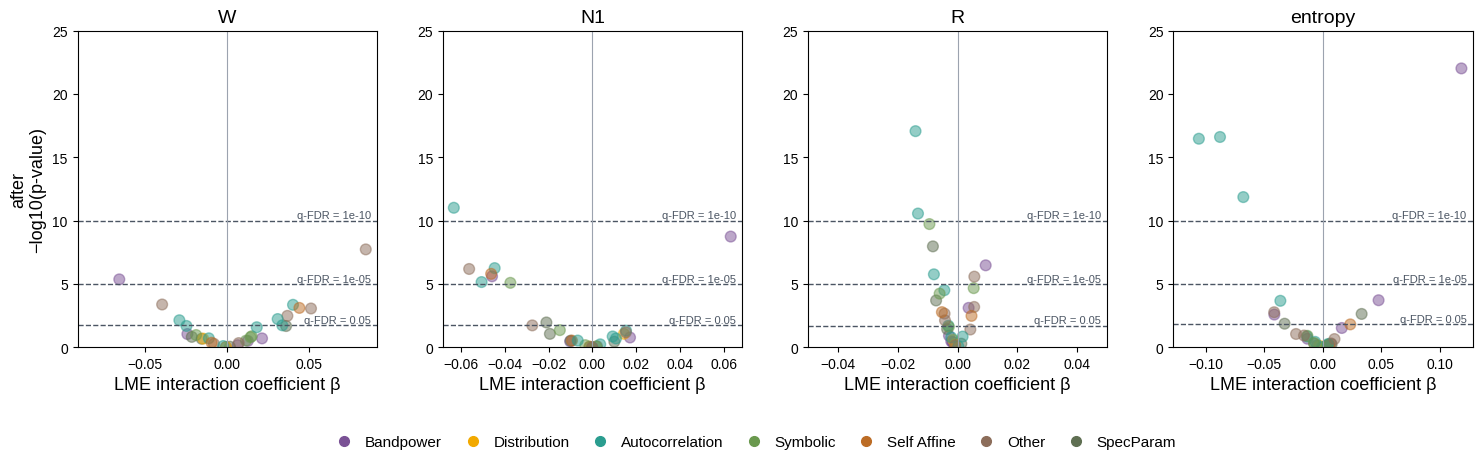

In [46]:
figure, axes = plt.subplots(1, 4, figsize=(18, 4.8), squeeze=False)
contrast = 'after'
for col, response in enumerate(target_order):
    axis = axes[0, col]
    target = delta_lme_results.loc[
        delta_lme_results['contrast'].eq(contrast) & delta_lme_results['response'].eq(response)
    ].copy()
    target['neg_log10_p'] = -np.log10(np.clip(target['p_value'], 1e-300, None))
    axis.scatter(target['estimate'], target['neg_log10_p'], s=60, alpha=0.5,
                 color=[CATEGORY_COLORS[FEATURE_CATEGORY[f]] for f in target['feature']])
    significant = target.loc[target['q_fdr'].lt(.05)]
    if not significant.empty:
        p_threshold = significant['p_value'].max()
        y_threshold = -np.log10(p_threshold)
        axis.axhline(y_threshold, color='#4b5563', linewidth=1, linestyle='--')
        axis.text(.98, y_threshold, 'q-FDR = 0.05', transform=axis.get_yaxis_transform(),
                  ha='right', va='bottom', fontsize=8, color='#4b5563')
    x_limit = max(target['estimate'].abs().max() * 1.08, .05)
    y_limit = max(25, target['neg_log10_p'].max() * 1.12)
    axis.set_xlim(-x_limit, x_limit); axis.set_ylim(0, y_limit)
    # labels = target.loc[target['neg_log10_p'].gt(10)].sort_values('neg_log10_p', ascending=False).copy()
    # labels['short_feature'] = labels['feature'].map(lambda feature: feature.split('_', 1)[1] if '_' in feature else feature)
    # labels = labels.reset_index(drop=True)
    # left_labels, right_labels = labels.iloc[::2], labels.iloc[1::2]
    # for side, side_labels in ((-1, left_labels), (1, right_labels)):
    #     if side_labels.empty:
    #         continue
    #     label_y_positions = np.linspace(y_limit * .80, y_limit * .25, len(side_labels))
    #     for label_y, (_, label_row) in zip(label_y_positions, side_labels.iterrows()):
    #         axis.annotate(textwrap.fill(label_row['short_feature'], width=12),
    #                       xy=(label_row['estimate'], label_row['neg_log10_p']),
    #                       xytext=(side * x_limit * .78, label_y),
    #                       ha='right' if side > 0 else 'left', va='center', fontsize=8.2,
    #                       color=CATEGORY_COLORS[FEATURE_CATEGORY[label_row['feature']]],
    #                       arrowprops={'arrowstyle': '-', 'linestyle': '--', 'linewidth': .5,
    #                                   'color': '#6b7280', 'shrinkA': 2, 'shrinkB': 2})
    for threshold in (5, 10):
        axis.axhline(threshold, color='#4b5563', linewidth=1, linestyle='--', zorder=2)
        axis.text(.98, threshold, f'q-FDR = {10 ** (-threshold):.0e}', transform=axis.get_yaxis_transform(),
                  ha='right', va='bottom', fontsize=8, color='#4b5563')
    axis.axvline(0, color='#9ca3af', linewidth=.8)
    axis.set_title(response)
    axis.set_xlabel('LME interaction coefficient β')
    axis.set_ylabel('after\n−log10(p-value)' if col == 0 else '')
category_handles = [Line2D([0], [0], marker='o', linestyle='', color=color, markersize=7, label=category) for category, color in CATEGORY_COLORS.items()]
figure.legend(handles=category_handles, loc='lower center', bbox_to_anchor=(.5, -.02), ncol=len(category_handles), frameon=False, columnspacing=1.0, handletextpad=.35)
figure.subplots_adjust(bottom=.22, top=.88, wspace=.22)
save_figure(figure, FIGURES_DIR / '05_delta_lme_volcano_after_by_target', formats=('png','svg','pdf')); plt.show()


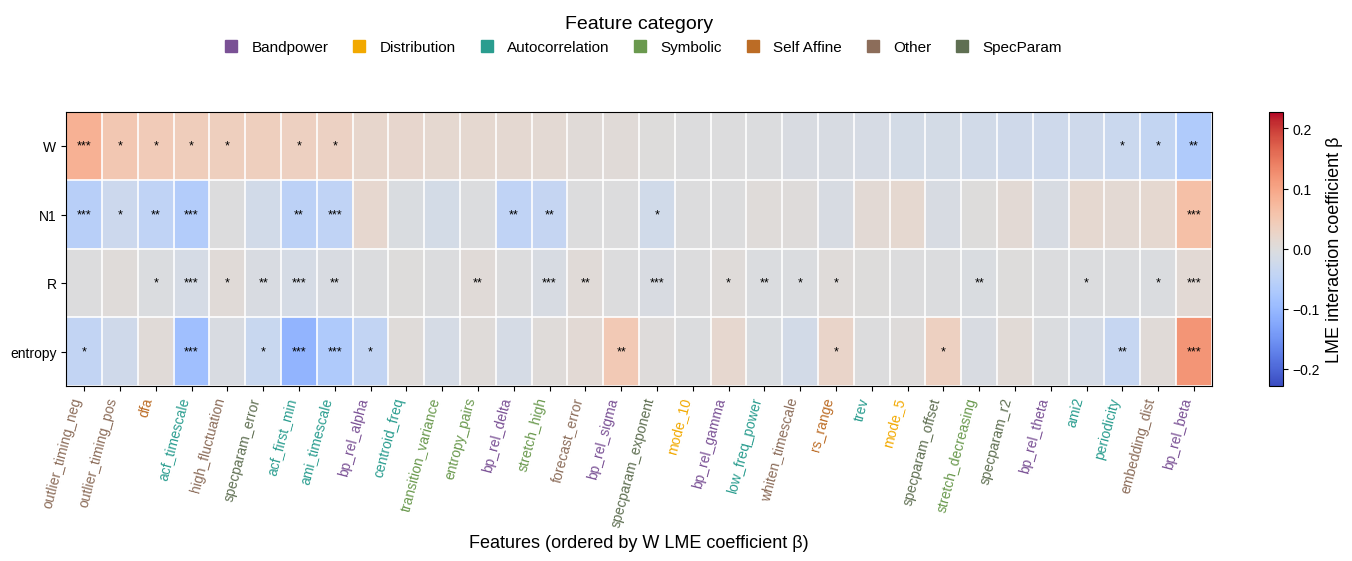

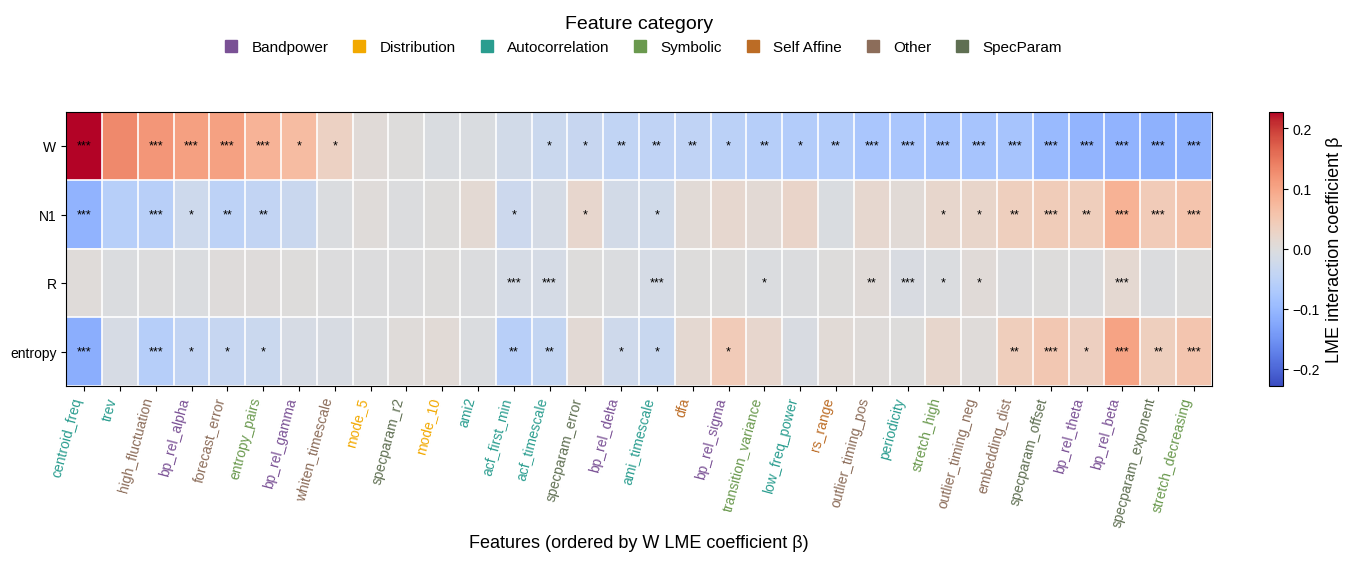

In [47]:
lme_source = delta_lme_results.copy()
lme_source['stars'] = np.select([lme_source['q_fdr'].lt(1e-5), lme_source['q_fdr'].lt(1e-3), lme_source['q_fdr'].lt(.05)], ['***', '**', '*'], default='')
beta_limit = np.nanmax(np.abs(lme_source['estimate'].to_numpy(float)))
for contrast in ('after', 'late'):
    contrast_data = lme_source.loc[lme_source['contrast'].eq(contrast)]
    feature_order = contrast_data.loc[contrast_data['response'].eq('W')].sort_values('estimate', ascending=False)['feature'].tolist()
    lme_matrix = contrast_data.pivot(index='response', columns='feature', values='estimate').reindex(index=target_order, columns=feature_order)
    lme_stars = contrast_data.pivot(index='response', columns='feature', values='stars').reindex(index=target_order, columns=feature_order).fillna('')
    figure, axis = plt.subplots(figsize=(max(12, .42 * len(feature_order)), 5.5), constrained_layout=True)
    image = axis.imshow(lme_matrix.to_numpy(float), vmin=-beta_limit, vmax=beta_limit, cmap='coolwarm', aspect='auto')
    axis.set_xticks(np.arange(len(feature_order)), [FEATURE_LABEL[f] for f in feature_order], rotation=75, ha='right'); axis.set_yticks(np.arange(len(target_order)), target_order)
    axis.set_xlabel('Features (ordered by W LME coefficient β)'); axis.set_ylabel('')
    axis.set_xticks(np.arange(-.5, len(feature_order), 1), minor=True); axis.set_yticks(np.arange(-.5, len(target_order), 1), minor=True)
    axis.grid(False, which='major'); axis.grid(which='minor', color='white', linewidth=1.2); axis.tick_params(which='minor', bottom=False, left=False)
    for label, feature in zip(axis.get_xticklabels(), feature_order): label.set_color(CATEGORY_COLORS[FEATURE_CATEGORY[feature]])
    for row, response in enumerate(target_order):
        for col, feature in enumerate(feature_order):
            axis.text(col, row, lme_stars.loc[response, feature], ha='center', va='center', color='black', fontsize=9)
    figure.colorbar(image, ax=axis, label='LME interaction coefficient β'); category_legend(axis)
    save_figure(figure, FIGURES_DIR / f'06_delta_lme_beta_matrix_{contrast}', formats=('png','svg','pdf')); plt.show()
